## Notebook 7: AC Electricity Consumption, Downscaling

In [1]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [4]:
# helper: picking first existing path from candidates 
def _first_existing(*cands, glob_pattern=None):
    for p in cands:
        p = Path(p)
        if p.exists():
            return p
    if glob_pattern is not None:
        hits = sorted(Path(OUT).glob(glob_pattern))
        if len(hits) == 1:
            return hits[0]
    return None

In [5]:
import numpy as np
import rasterio as rio
import geopandas as gpd
import pandas as pd
from pathlib import Path

# FUA / Regions paths
fua_gpkg = Path(paths.get("fua_gpkg", OUT / f"{SLUG}_fua.gpkg"))
fua_gpkg = _first_existing(fua_gpkg, OUT / "fua.gpkg", glob_pattern="*_fua.gpkg")
assert fua_gpkg and fua_gpkg.exists(), "Missing FUA geopackage."

regions_gpkg = Path(paths.get("regions_gpkg", OUT / f"{SLUG}_regions.gpkg"))
regions_gpkg = _first_existing(regions_gpkg, OUT / "regions.gpkg", glob_pattern="*_regions.gpkg")
assert regions_gpkg and regions_gpkg.exists(), "Missing regions geopackage."

muni_on_ref_tif = Path(paths.get("muni_on_ref_tif", OUT / f"{SLUG}_muni_on_ref.tif"))
muni_on_ref_tif = _first_existing(muni_on_ref_tif, OUT / "muni_on_ref.tif", glob_pattern="*_muni_on_ref.tif")
assert muni_on_ref_tif and muni_on_ref_tif.exists(), "Missing muni_on_ref.tif (save it in NB5)."

# LUTs
muni_lut_csv = Path(paths.get("muni_lut_csv", OUT / f"{SLUG}_muni_lut.csv"))
muni_lut_csv = _first_existing(muni_lut_csv, OUT / "muni_lut.csv", glob_pattern="*_muni_lut.csv")
assert muni_lut_csv and muni_lut_csv.exists(), "Missing muni_lut.csv (save it in NB5)."

lut = (
    pd.read_csv(muni_lut_csv)
    .assign(muni_id=lambda d: d["muni_id"].astype(int))
    .sort_values("muni_id")
)
print("Using muni LUT:", muni_lut_csv.name, "| rows:", len(lut))

cap_gpkg = Path(paths.get("cap_gpkg", OUT / f"{SLUG}_cap.gpkg"))
cap_gpkg = _first_existing(cap_gpkg, OUT / "cap.gpkg", glob_pattern="*_cap.gpkg")
assert cap_gpkg and cap_gpkg.exists(), "Missing CAP geopackage."

cap_lut_csv = Path(paths.get("cap_lut_csv", OUT / f"{SLUG}_cap_lut.csv"))
cap_lut_csv = _first_existing(cap_lut_csv, OUT / "cap_lut.csv", glob_pattern="*_cap_lut.csv")
assert cap_lut_csv and cap_lut_csv.exists(), "Missing cap_lut.csv (save it in NB6)."

cap_ref_lut = (pd.read_csv(cap_lut_csv).astype({"cap_id": int, "cap5": str}).drop_duplicates())
print("Using CAP LUT:", cap_lut_csv.name, "| rows:", len(cap_ref_lut))

cap_wgs84_lut_path = Path(paths.get("cap_wgs84_lut", OUT / f"{SLUG}_cap_wgs84_lut.csv"))
cap_wgs84_lut_path = _first_existing(cap_wgs84_lut_path, OUT / "cap_wgs84_lut.csv", glob_pattern="*_cap_wgs84_lut.csv")
cap_wgs84_lut_df = None
if cap_wgs84_lut_path and cap_wgs84_lut_path.exists():
    cap_wgs84_lut_df = (pd.read_csv(cap_wgs84_lut_path).astype({"cap_id": int, "cap5": str}).drop_duplicates())
    print("Using CAP WGS84 LUT:", cap_wgs84_lut_path.name)

# Reference grid + city mask
tmpl_path = INT / "template_ref.tif" # T2M ref grid
mask_tif = INT / "city_mask.tif" # boolean mask on that grid
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
HGT, WDT = ref_meta["height"], ref_meta["width"]
with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

# Hot-days stack
# T2M hazard stack on ref grid (mean daily T2M per year)
t2m_npz_path = _first_existing(
    INT / f"t2m_hazard_2030_2100_{SLUG}.npz",
    INT / "t2m_hazard_2030_2100.npz",
    glob_pattern="t2m_hazard_2030_2100*.npz"
)
assert t2m_npz_path and t2m_npz_path.exists(), "Missing T2M hazard .npz (run NB3)."

npz = np.load(t2m_npz_path)
YEARS = npz["years"].astype(int) # (n_years,)
DATA = npz["data"].astype("float32") # (n_years, HGT, WDT)
assert DATA.shape[1:] == (HGT, WDT), f"T2M hazard grid {DATA.shape[1:]} != ref grid {(HGT, WDT)}"
H2050 = DATA[list(YEARS).index(2050)]
print("Loaded T2M hazard:", t2m_npz_path.name, "| years:", YEARS.min(), "→", YEARS.max())

# AC coverage
# loading AC targets (city mean shares) produced by NB5 
targets_path = INT / f"ac_city_targets_{SLUG}.csv"
t = pd.read_csv(targets_path)
ac_city_by_year = dict(zip(t["year"].astype(int), t["ac_share"].astype(float)))

# loading AC coverage maps (CAP-based maps) produced by NB5 
cov_path = INT / f"ac_coverage_maps_{SLUG}.npz"
z = np.load(cov_path)
YEARS_COV = z["YEARS_AC"].astype(int).tolist()
year_to_k = {y: i for i, y in enumerate(YEARS_COV)}

coverage_base_3d = z["coverage_base_3d"].astype("float32")
coverage_policy_3d = z["coverage_policy_3d"].astype("float32")

def cov_base_for_year(y: int) -> np.ndarray:
    return coverage_base_3d[year_to_k[int(y)]]

def cov_policy_for_year(y: int) -> np.ndarray:
    return coverage_policy_3d[year_to_k[int(y)]]

# Population / CAP rasters
def _load_pop_on_ref(INT, SLUG, HGT, WDT):
    pop_npz_path = _first_existing(
        INT / f"pop_on_ref_{SLUG}.npz",
        INT / "pop_on_ref.npz",
        glob_pattern="pop_on_ref*.npz"
    )
    if pop_npz_path and pop_npz_path.exists():
        pop = np.load(pop_npz_path)["pop"].astype("float32")
    else:
        # fallback to GeoTIFF saved in NB5
        with rio.open(INT / "pop_on_ref.tif") as src:
            pop = src.read(1).astype("float32")
            assert (src.height, src.width) == (HGT, WDT), "pop_on_ref.tif grid mismatch."
    assert pop.shape == (HGT, WDT), f"pop_on_ref shape {pop.shape} != {(HGT, WDT)}"
    return pop

def _load_age_on_ref(INT, SLUG, HGT, WDT):
    age_npz_path = _first_existing(
        INT / f"age_on_ref_{SLUG}.npz",
        INT / "age_on_ref.npz",
        glob_pattern="age_on_ref*.npz"
    )
    if age_npz_path and age_npz_path.exists():
        d = np.load(age_npz_path)
        age = {"<15": d["lt15"].astype("float32"), "15-64": d["a15_64"].astype("float32"), "65+": d["g65"].astype("float32")}
    else:
        # fallback to per-band GeoTIFFs saved in NB5
        age = {}
        with rio.open(INT / "age_lt15_on_ref.tif") as s:
            age["<15"] = s.read(1).astype("float32")
        with rio.open(INT / "age_15_64_on_ref.tif") as s:
            age["15-64"] = s.read(1).astype("float32")
        with rio.open(INT / "age_65p_on_ref.tif") as s:
            age["65+"] = s.read(1).astype("float32")
    for k,v in age.items():
        assert v.shape == (HGT, WDT), f"age {k} shape {v.shape} != {(HGT, WDT)}"
    return age

# using them
pop_on_ref = _load_pop_on_ref(INT, SLUG, HGT, WDT)
age_on_ref = _load_age_on_ref(INT, SLUG, HGT, WDT)

print(
    "Loaded exposure:",
    f"\n pop_on_ref: {pop_on_ref.shape}, sum={np.nansum(pop_on_ref):.0f}",
    f"\n age lt15: {age_on_ref['<15'].shape}, sum={np.nansum(age_on_ref['<15']):.0f}",
    f"\n age 15-64: {age_on_ref['15-64'].shape}, sum={np.nansum(age_on_ref['15-64']):.0f}",
    f"\n age 65+: {age_on_ref['65+'].shape}, sum={np.nansum(age_on_ref['65+']):.0f}",
)

# CAP raster on ref grid
def _load_cap_on_ref(INT, SLUG, HGT, WDT):
    cap_npz_path = _first_existing(
        INT / f"cap_on_ref_{SLUG}.npz",
        INT / "cap_on_ref.npz",
        glob_pattern="cap_on_ref*.npz"
    )
    if cap_npz_path and cap_npz_path.exists():
        cap = np.load(cap_npz_path)["cap_on_ref"].astype("int32")
    else:
        # fallback to GeoTIFF written in NB6
        with rio.open(INT / f"cap_on_ref_{SLUG}.tif") as src:
            cap = src.read(1).astype("int32")
            assert (src.height, src.width) == (HGT, WDT), "cap_on_ref.tif grid mismatch."
    assert cap.shape == (HGT, WDT), f"cap_on_ref shape {cap.shape} != {(HGT, WDT)}"
    return cap

cap_on_ref = _load_cap_on_ref(INT, SLUG, HGT, WDT)

# Optional: CAP_MASK from coverage NPZ if present, else derive from CAP raster
if "CAP_MASK" in z.files:
    CAP_MASK = z["CAP_MASK"].astype(bool)
else:
    CAP_MASK = (CITY_MASK & (cap_on_ref > 0))

# Vectors
fua = gpd.read_file(fua_gpkg).to_crs("EPSG:4326")
regions = gpd.read_file(regions_gpkg, layer="regions").set_crs("EPSG:4326")
muni = gpd.read_file(regions_gpkg, layer="muni").set_crs("EPSG:4326")

with rio.open(muni_on_ref_tif) as src:
    muni_on_ref = src.read(1).astype("int32")
    assert (src.crs == ref_meta["crs"]) and (src.transform == ref_meta["transform"]), "Grid mismatch."

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)
print("Unique muni IDs on grid (>=0):", int(np.unique(muni_on_ref[muni_on_ref >= 0]).size))

cap_ref = gpd.read_file(cap_gpkg, layer="cap").to_crs(ref_meta["crs"])
cap_4326 = gpd.read_file(cap_gpkg, layer="cap_wgs84").to_crs("EPSG:4326")

print(
    "Loaded:",
    "\n FUA:", fua_gpkg.name,
    "\n Regions:", regions_gpkg.name,
    "\n muni_on_ref:", muni_on_ref_tif.name, muni_on_ref.shape,
    "\n CAPs:", cap_gpkg.name
)

Using muni LUT: rome_muni_lut.csv | rows: 16
Using CAP LUT: rome_cap_lut.csv | rows: 118
Using CAP WGS84 LUT: rome_cap_wgs84_lut.csv
Loaded T2M hazard: t2m_hazard_2030_2100_rome.npz | years: 2030 → 2050
Loaded exposure: 
 pop_on_ref: (301, 301), sum=2548154 
 age lt15: (301, 301), sum=277144 
 age 15-64: (301, 301), sum=1580341 
 age 65+: (301, 301), sum=690669
Loaded regions: 16 polygons; muni_on_ref shape: (301, 301)
Unique muni IDs on grid (>=0): 16
Loaded: 
 FUA: rome_fua.gpkg 
 Regions: rome_regions.gpkg 
 muni_on_ref: rome_muni_on_ref.tif (301, 301) 
 CAPs: rome_cap.gpkg


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Parametrisation of the AC costs: using the gridded AC data : divide TWh layers by pop layers, convert units to get average AC electricity use (kWh / capita + year)
</blockquote>

**Loading the data**

In [6]:
# AC kWh per AC-user (city) from NUTS CSV (no NetCDF / no pixel)
import pandas as pd
import numpy as np
import re

ac_cfg = cfg.get("ac", {})
kwh_path = P(ac_cfg.get("kwh_file", ""))
assert kwh_path.exists(), f"Missing AC kWh CSV: {kwh_path}"

# settings from YAML
ssp_choice = int(ac_cfg.get("ssp", 2))
years_interest = list(ac_cfg.get("years", [2030, 2040, 2050]))
nuts_id = ac_cfg.get("nuts_id", None)
assert nuts_id, "cfg['ac']['nuts_id'] missing (e.g. 'ITI43')."

cols = ac_cfg.get("kwh_columns", {}) or {}
COL_ID = cols.get("id", "NUTS_ID")
COL_SSP = cols.get("scenario", "Scenario")
COL_YEAR = cols.get("year", "year")
COL_VAL = cols.get("value", "value")

df = pd.read_csv(kwh_path)

# basic column check
need = [COL_ID, COL_SSP, COL_YEAR, COL_VAL]
missing = [c for c in need if c not in df.columns]
assert not missing, f"Missing columns in {kwh_path.name}: {missing}. Found: {list(df.columns)}"

# normalising scenario to an integer SSP number when possible
def _ssp_to_int(x):
    s = str(x)
    m = re.search(r"(\d+)", s)
    return int(m.group(1)) if m else None

df = df.copy()
df["_ssp_int"] = df[COL_SSP].map(_ssp_to_int)
df[COL_YEAR] = pd.to_numeric(df[COL_YEAR], errors="coerce")
df[COL_VAL] = pd.to_numeric(df[COL_VAL], errors="coerce").replace([-999, -9999], np.nan)

# filter
sub = df[(df[COL_ID].astype(str) == str(nuts_id)) & (df["_ssp_int"] == ssp_choice)].dropna(subset=[COL_YEAR, COL_VAL])
assert len(sub) > 0, (
    f"No rows found for NUTS_ID={nuts_id} and SSP={ssp_choice} in {kwh_path.name}. "
    f"Check values in columns {COL_ID} / {COL_SSP}."
)

# if duplicates exist, take mean per year 
series = (sub.groupby(sub[COL_YEAR].astype(int))[COL_VAL].mean()).to_dict()

# build dict for requested years
missing_years = [y for y in years_interest if int(y) not in series]
assert not missing_years, f"Missing years in AC kWh CSV for {nuts_id}, SSP{ssp_choice}: {missing_years}"

per_user_city_by_year = {int(y): float(series[int(y)]) for y in years_interest}
per_user_city = float(per_user_city_by_year[max(years_interest)])

print("AC per-AC-user from NUTS CSV (kWh/user/yr):")
for y in years_interest:
    print(f" {y}: {per_user_city_by_year[int(y)]:.3f}")

# save CSV for NB8 
ac_city_series = pd.DataFrame({
    "year": years_interest,
    "kwh_per_ac_user_city": [per_user_city_by_year[int(y)] for y in years_interest],
})

out_csv = INT / f"ac_per_user_city_{SLUG}.csv"
ac_city_series.to_csv(out_csv, index=False)
print("Saved:", out_csv)

AC per-AC-user from NUTS CSV (kWh/user/yr):
 2030: 954.202
 2040: 954.202
 2050: 1001.772
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_per_user_city_rome.csv


**Downscaling the AC electricity consumption at the CAP level**: based not on the income but on the hazard level

**Question of the shape**: message of Giacomo: following the approach we used to create a variation across CAPs from a single datapoint for AC, also create a variation in consumption. The data point is already in per AC-user, so we just need to create a spread that follows a normal distribution with mean = the pixel value and proportional to the local heat levels

In [7]:
import numpy as np
import pandas as pd

# We now rely on per-year dict from the NetCDF step
assert ("per_user_city_by_year" in globals() and isinstance(per_user_city_by_year, dict) and len(per_user_city_by_year) > 0), \
 "per_user_city_by_year must be defined by the NetCDF/FUA selection cell."

years_interest = [2030, 2040, 2050]
pop_grid = pop_on_ref
cap_ids = cap_on_ref

def _get_H_for_year(year):
    if year not in YEARS:
        raise KeyError(f"Year {year} not found in T2M YEARS: {list(YEARS)}")
    idx = list(YEARS).index(int(year))
    return DATA[idx, :, :]

def _cov_for_year(year):
    """ Return AC coverage map for a given year from the NB5 3D maps.
    NB5 already did the year-specific calibration, so no extra rescaling here.
    """
    year = int(year)
    if year not in year_to_k:
        raise KeyError(f"Year {year} not in YEARS_COV (from NB5): {YEARS_COV}")
    base = cov_base_for_year(year).astype("float32")
    return np.clip(base, 0.0, 1.0).astype("float32")

rng = np.random.default_rng(42)
sigma0 = 0.20 # base dispersion (20% of mean)
gamma = 1.0 # how strongly dispersion scales with hazard ratio

**CAP Maps or tables:**

In [8]:
# drawing ONE eps per CAP ONCE, and reuse it for all years 
# Use 2030 only to define the CAP set (ids) consistently.
H0 = _get_H_for_year(2030)
CAP_PIX0 = CITY_MASK & np.isfinite(H0) & (cap_ids > 0)
valid0 = CAP_PIX0 & np.isfinite(pop_grid)

dfH0 = pd.DataFrame({
    "cap_id": cap_ids[valid0].ravel().astype(int),
    "pop": pop_grid[valid0].ravel().astype(float),
    "H": H0[valid0].ravel().astype(float),
})

def _wavg_pop(g):
    w = g["pop"].to_numpy()
    x = g["H"].to_numpy()
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

cap_ids_all = (dfH0["cap_id"].drop_duplicates().sort_values().to_numpy())
eps_by_cap = dict(zip(cap_ids_all, rng.normal(0.0, 1.0, size=len(cap_ids_all))))


=== Year 2030 ===
AC share from map (city pop-weighted): 0.662
AC share from NB5 (target): 0.662
Per-user mean (city): 954.2021484375
AC share from map:  0.6619395017623901
City total GWh:  1609.475584

=== Year 2040 ===
AC share from map (city pop-weighted): 0.715
AC share from NB5 (target): 0.715
Per-user mean (city): 954.2023315429688
AC share from map:  0.7148963809013367
City total GWh:  1738.23808

=== Year 2050 ===
AC share from map (city pop-weighted): 0.715
AC share from NB5 (target): 0.715
Per-user mean (city): 1001.7722778320312
AC share from map:  0.7148963809013367
City total GWh:  1824.89408


,year,ac_share_city,ac_share_from_map,per_user_city_input,per_user_city_realized,city_total_GWh
0,2030,0.661939,0.661940,954.202148,954.202148,1609.475584
1,2040,0.714896,0.714896,954.202148,954.202332,1738.238080
2,2050,0.714896,0.714896,1001.772156,1001.772278,1824.894080



==== CAP-level results for year 2030 ====
City pop: 2,548,154
City AC users: 1,686,724 (AC share ≈ 0.662)
City total AC electricity: 1609.476 GWh/yr
City per-AC-user mean (users-weighted): 954.202377 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.767892,1348.728760,44494.561070,4.608202e+07,1035.677614,2030
1,78,0.943288,1094.054810,21992.931191,2.269691e+07,1032.009158,2030
2,110,0.965383,1050.522217,28695.673471,2.910190e+07,1014.156432,2030
3,107,0.946537,1066.344604,9290.892429,9.377618e+06,1009.334472,2030
4,105,0.933163,1022.865356,24897.301921,2.376447e+07,954.500003,2030
5,71,0.889188,1058.083008,32908.613010,3.096158e+07,940.835021,2030
6,112,0.920665,1016.088867,23655.270482,2.212896e+07,935.476990,2030
7,66,0.853804,1050.305664,15601.997372,1.399117e+07,896.754760,2030
8,109,0.924949,961.651978,15981.706853,1.421539e+07,889.478575,2030
9,61,0.870721,1016.141174,36202.427533,3.203102e+07,884.775451,2030


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.466687,623.928833,27875.780769,8.116847e+06,291.179169,2030
1,53,0.369616,803.711182,103728.386679,3.081400e+07,297.064331,2030
2,103,0.410963,732.746521,11587.980538,3.489509e+06,301.131805,2030
3,87,0.399803,811.674500,20995.874449,6.813373e+06,324.510071,2030
4,88,0.385820,880.026245,35544.090550,1.206835e+07,339.531861,2030
5,86,0.405870,840.707886,34966.397290,1.193116e+07,341.217773,2030
6,52,0.381198,898.809814,8590.451368,2.943296e+06,342.624144,2030
7,93,0.431328,869.402832,27316.795516,1.024374e+07,374.997772,2030
8,41,0.357401,1084.355835,17621.180532,6.829082e+06,387.549622,2030
9,48,0.393544,997.635315,37363.317353,1.466932e+07,392.612945,2030



Top 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.783808,1011.934265,80341.231492,6.372363e+07,793.162231,2030
1,83,0.448772,1048.566528,124767.276103,5.871145e+07,470.567688,2030
2,55,0.824477,903.065735,77077.603001,5.738864e+07,744.556580,2030
3,63,0.910197,852.471802,72016.976061,5.587920e+07,775.917054,2030
4,62,0.767892,1348.728760,44494.561070,4.608202e+07,1035.677614,2030
5,59,0.629838,996.053528,66337.303481,4.161684e+07,627.352052,2030
6,50,0.726416,1097.317993,49859.790069,3.974370e+07,797.109315,2030
7,89,0.574188,1219.225708,56324.068493,3.943047e+07,700.064269,2030
8,82,0.861090,986.853943,45832.143144,3.894677e+07,849.769713,2030
9,73,0.532605,1032.502441,70384.133361,3.870537e+07,549.916138,2030


Bottom 10 CAPs by kwh_cap — Total kWh, 2030


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.706851,1083.379639,220.220836,1.686424e+05,765.787860,2030
1,21,0.677359,686.857788,1151.152281,5.355729e+05,465.249420,2030
2,24,0.704482,876.889343,2401.749023,1.483687e+06,617.752563,2030
3,44,0.550133,943.110901,3973.220491,2.061453e+06,518.836732,2030
4,19,0.694107,572.492432,5608.371942,2.228606e+06,397.371276,2030
5,52,0.381198,898.809814,8590.451368,2.943296e+06,342.624144,2030
6,103,0.410963,732.746521,11587.980538,3.489509e+06,301.131805,2030
7,3,0.678759,755.888306,9452.473559,4.849741e+06,513.065857,2030
8,33,0.705810,928.579529,7703.112589,5.048624e+06,655.400574,2030
9,87,0.399803,811.674500,20995.874449,6.813373e+06,324.510071,2030


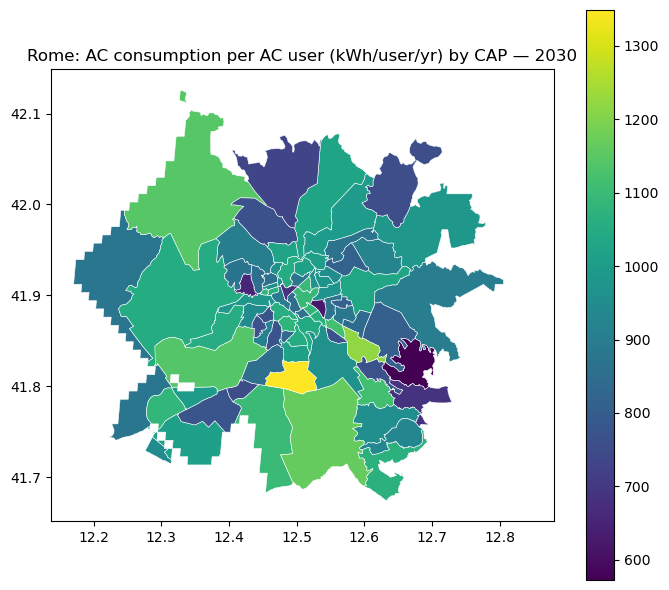

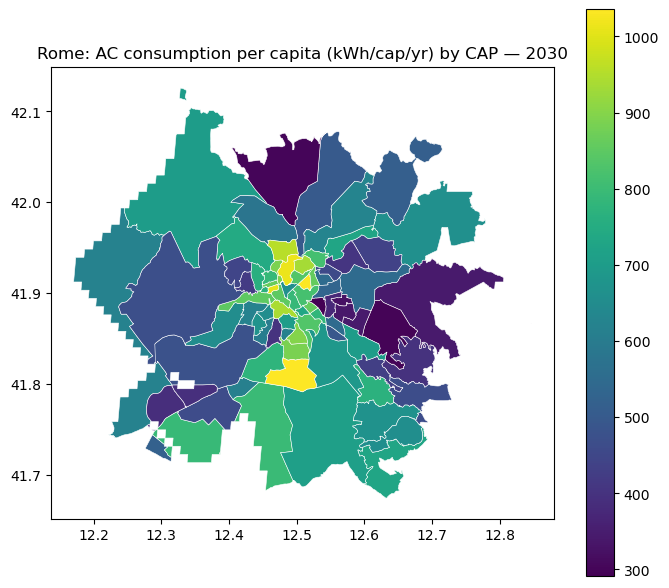


==== CAP-level results for year 2040 ====
City pop: 2,548,154
City AC users: 1,821,666 (AC share ≈ 0.715)
City total AC electricity: 1738.238 GWh/yr
City per-AC-user mean (users-weighted): 954.202283 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.835731,1348.265259,44494.561070,5.013591e+07,1126.787474,2040
1,78,0.980000,1093.823608,21992.931191,2.357526e+07,1071.947151,2040
2,107,0.980000,1066.062256,9290.892429,9.706577e+06,1044.741089,2040
3,110,0.980000,1050.278564,28695.673471,2.953568e+07,1029.273071,2040
4,71,0.968490,1057.809082,32908.613010,3.371414e+07,1024.477659,2040
5,105,0.980000,1022.663147,24897.301921,2.495232e+07,1002.209900,2040
6,112,0.980000,1015.880920,23655.270482,2.355032e+07,995.563292,2040
7,66,0.929762,1050.046143,15601.997372,1.523212e+07,976.292724,2040
8,61,0.948278,1015.885071,36202.427533,3.487529e+07,963.341248,2040
9,109,0.980000,961.444580,15981.706853,1.505822e+07,942.215700,2040


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.506063,623.742249,27875.780769,8.799065e+06,315.652681,2040
1,53,0.399819,803.552368,103728.386679,3.332538e+07,321.275451,2040
2,103,0.445074,732.468018,11587.980538,3.777707e+06,326.002166,2040
3,87,0.432859,811.513489,20995.874449,7.375240e+06,351.270936,2040
4,88,0.417555,879.844299,35544.090550,1.305830e+07,367.383026,2040
5,86,0.439499,840.563110,34966.397290,1.291751e+07,369.426392,2040
6,52,0.412495,898.604614,8590.451368,3.184224e+06,370.670104,2040
7,93,0.467363,869.218140,27316.795516,1.109718e+07,406.240236,2040
8,41,0.386450,1084.239380,17621.180532,7.383344e+06,419.003937,2040
9,48,0.426008,997.452393,37363.317353,1.587652e+07,424.922546,2040



Top 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.853152,1011.787537,80341.231492,6.935121e+07,863.208251,2040
1,83,0.486456,1048.353149,124767.276103,6.362849e+07,509.977387,2040
2,55,0.897663,902.872864,77077.603001,6.246954e+07,810.475952,2040
3,63,0.980000,852.325562,72016.976061,6.015427e+07,835.279052,2040
4,62,0.835731,1348.265259,44494.561070,5.013591e+07,1126.787474,2040
5,59,0.684631,995.878418,66337.303481,4.522941e+07,681.809632,2040
6,50,0.790336,1097.067017,49859.790069,4.323102e+07,867.051818,2040
7,89,0.623722,1218.880005,56324.068493,4.281997e+07,760.242798,2040
8,82,0.937736,986.632996,45832.143144,4.240397e+07,925.201539,2040
9,73,0.578211,1032.286621,70384.133361,4.201081e+07,596.879028,2040


Bottom 10 CAPs by kwh_cap — Total kWh, 2040


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.768922,1083.086426,220.220836,1.834019e+05,832.809209,2040
1,21,0.736644,686.733093,1151.152281,5.823421e+05,505.877533,2040
2,24,0.766329,876.663086,2401.749023,1.613525e+06,671.812561,2040
3,44,0.597395,942.920288,3973.220491,2.238099e+06,563.295960,2040
4,19,0.754975,572.330566,5608.371942,2.423350e+06,432.095031,2040
5,52,0.412495,898.604614,8590.451368,3.184224e+06,370.670104,2040
6,103,0.445074,732.468018,11587.980538,3.777707e+06,326.002166,2040
7,3,0.738175,755.555969,9452.473559,5.271955e+06,557.732849,2040
8,33,0.767783,928.382812,7703.112589,5.490751e+06,712.796385,2040
9,87,0.432859,811.513489,20995.874449,7.375240e+06,351.270936,2040


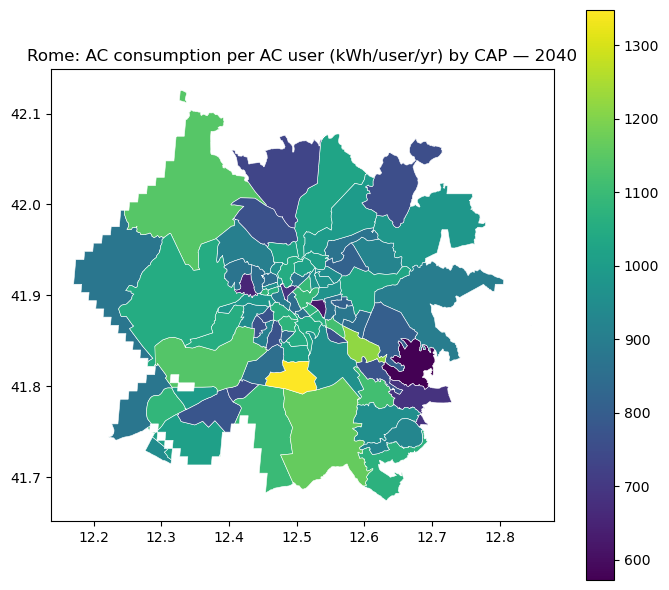

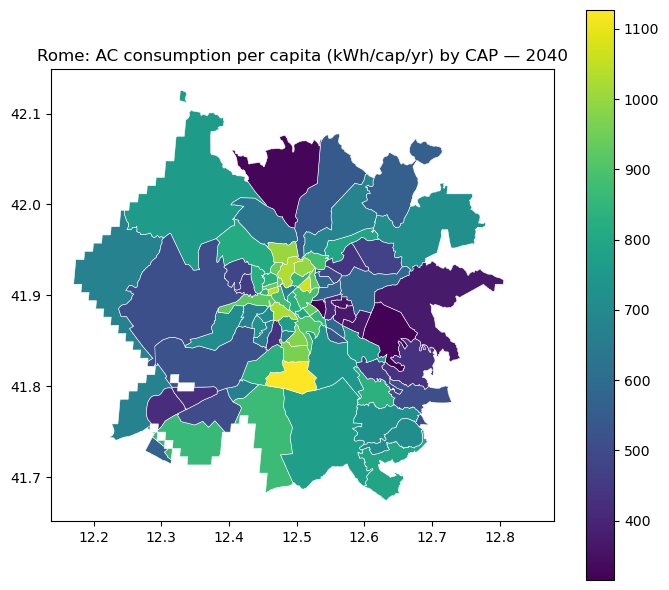


==== CAP-level results for year 2050 ====
City pop: 2,548,154
City AC users: 1,821,666 (AC share ≈ 0.715)
City total AC electricity: 1824.894 GWh/yr
City per-AC-user mean (users-weighted): 1001.772152 kWh/user/yr

Top 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,62,0.835731,1415.276611,44494.561070,5.262776e+07,1182.790893,2050
1,78,0.980000,1148.356079,21992.931191,2.475060e+07,1125.389037,2050
2,107,0.980000,1119.139160,9290.892429,1.018985e+07,1096.756348,2050
3,110,0.980000,1102.613159,28695.673471,3.100742e+07,1080.560911,2050
4,71,0.968490,1110.485718,32908.613010,3.539303e+07,1075.494510,2050
5,105,0.980000,1073.665161,24897.301921,2.619674e+07,1052.191895,2050
6,112,0.980000,1066.535889,23655.270482,2.472461e+07,1045.205197,2050
7,66,0.929762,1102.351440,15601.997372,1.599086e+07,1024.924191,2050
8,61,0.948278,1066.483887,36202.427533,3.661235e+07,1011.322938,2050
9,109,0.980000,1009.372253,15981.706853,1.580886e+07,989.184815,2050


Bottom 10 CAPs by kwh_pc_overall — kWh per capita (overall), 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,92,0.506063,654.768860,27875.780769,9.236754e+06,331.354095,2050
1,53,0.399819,843.625549,103728.386679,3.498732e+07,337.297455,2050
2,103,0.445074,768.847168,11587.980538,3.965332e+06,342.193542,2050
3,87,0.432859,851.981384,20995.874449,7.743023e+06,368.787843,2050
4,88,0.417555,923.713074,35544.090550,1.370938e+07,385.700622,2050
5,86,0.439499,882.507507,34966.397290,1.356210e+07,387.860900,2050
6,52,0.412495,943.385986,8590.451368,3.342907e+06,389.142212,2050
7,93,0.467363,912.551208,27316.795516,1.165041e+07,426.492492,2050
8,41,0.386450,1138.420532,17621.180532,7.752301e+06,439.942231,2050
9,48,0.426008,1047.211304,37363.317353,1.666853e+07,446.120209,2050



Top 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,46,0.853152,1062.309814,80341.231492,7.281417e+07,906.311401,2050
1,83,0.486456,1100.626343,124767.276103,6.680114e+07,535.405945,2050
2,55,0.897663,947.883667,77077.603001,6.558383e+07,850.880493,2050
3,63,0.980000,894.858643,72016.976061,6.315611e+07,876.961488,2050
4,62,0.835731,1415.276611,44494.561070,5.262776e+07,1182.790893,2050
5,59,0.684631,1045.572144,66337.303481,4.748633e+07,715.831544,2050
6,50,0.790336,1151.738525,49859.790069,4.538541e+07,910.260679,2050
7,89,0.623722,1279.542969,56324.068493,4.495109e+07,798.079650,2050
8,82,0.937736,1035.806030,45832.143144,4.451735e+07,971.312865,2050
9,73,0.578211,1083.757080,70384.133361,4.410550e+07,626.639831,2050


Bottom 10 CAPs by kwh_cap — Total kWh, 2050


,cap_id,ac_share_cap,kwh_per_user_cap,pop_cap,kwh_cap,kwh_pc_overall,year
0,42,0.768922,1137.003052,220.220836,1.925318e+05,874.266899,2050
1,21,0.736644,720.996338,1151.152281,6.113970e+05,531.117370,2050
2,24,0.766329,920.321472,2401.749023,1.693880e+06,705.269225,2050
3,44,0.597395,989.939453,3973.220491,2.349703e+06,591.385008,2050
4,19,0.754975,600.811462,5608.371942,2.543943e+06,453.597381,2050
5,52,0.412495,943.385986,8590.451368,3.342907e+06,389.142212,2050
6,103,0.445074,768.847168,11587.980538,3.965332e+06,342.193542,2050
7,3,0.738175,793.011536,9452.473559,5.533305e+06,585.381653,2050
8,33,0.767783,974.667114,7703.112589,5.764491e+06,748.332640,2050
9,87,0.432859,851.981384,20995.874449,7.743023e+06,368.787843,2050


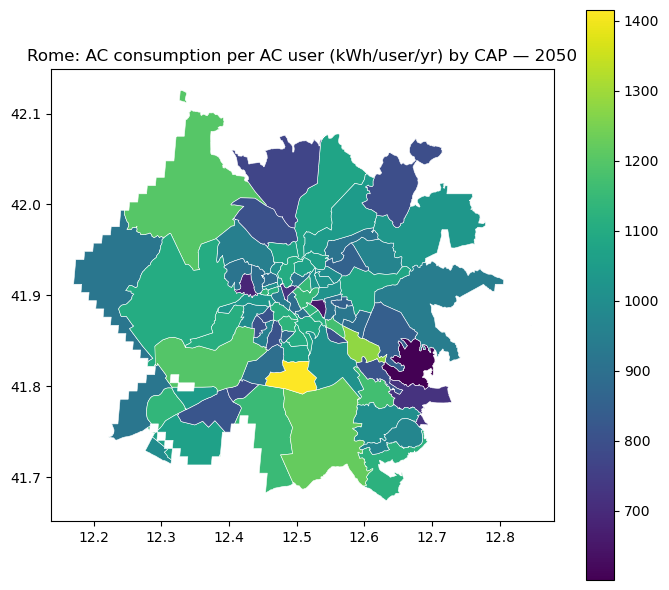

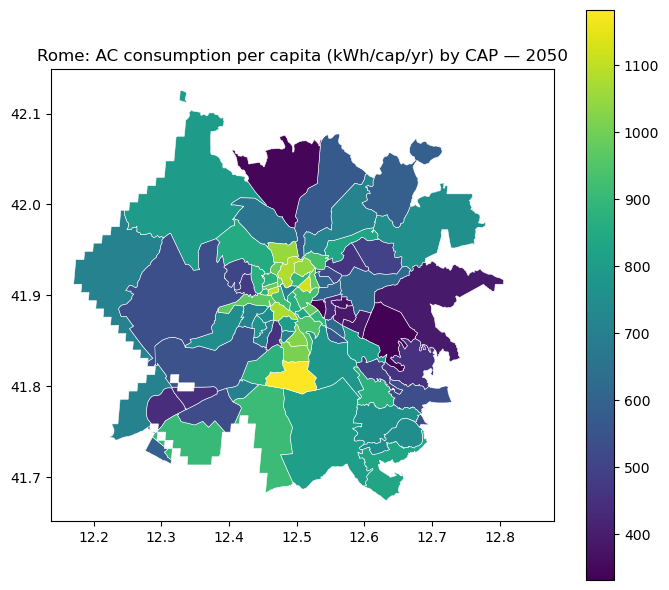

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_cap_ac_consumption_map.geojson


In [9]:
per_user_map_by_year = {}
kwh_tot_map_by_year = {}
cap_per_user_by_year = {}
cap_energy_by_year = {}
city_summary_rows = []

for year in years_interest:
    print(f"\n=== Year {year} ===")

    # inputs for this year
    coverage_map = _cov_for_year(year) # AC penetration map
    H_year = _get_H_for_year(year) # hazard index
    per_user_city = float(per_user_city_by_year[year]) # kWh per AC user (city)

    # citywide AC share from the map
    m = CITY_MASK & np.isfinite(coverage_map) & np.isfinite(pop_grid)
    ac_city_map = float(np.nansum(coverage_map[m] * pop_grid[m]) / np.nansum(pop_grid[m]))

    # target AC share from NB5, if available
    if "ac_city_by_year" in globals() and year in ac_city_by_year:
        ac_city_target = float(ac_city_by_year[year])
    else:
        ac_city_target = ac_city_map

    print(f"AC share from map (city pop-weighted): {ac_city_map:.3f}")
    print(f"AC share from NB5 (target): {ac_city_target:.3f}")

    # CAP-level hazard index (pop-weighted) for dispersion
    CAP_PIX = CITY_MASK & np.isfinite(H_year) & (cap_ids > 0)
    valid = CAP_PIX & np.isfinite(pop_grid)

    dfH = pd.DataFrame({
        "cap_id": cap_ids[valid].ravel().astype(int),
        "pop": pop_grid[valid].ravel().astype(float),
        "H": H_year[valid].ravel().astype(float),
    })

    cap_H = (dfH.groupby("cap_id").apply(_wavg_pop)
             .reset_index(name="H_cap")
             .sort_values("cap_id")
             .reset_index(drop=True))

    H_city = (float(np.average(dfH["H"], weights=dfH["pop"])) if dfH["pop"].sum() > 0 else float(dfH["H"].mean()))

    # fixed eps per CAP (same CAP is always "high" or "low" across years)
    eps = cap_H["cap_id"].map(eps_by_cap).to_numpy(float)

    cap_draws = cap_H.copy()
    ratio = np.clip((cap_draws["H_cap"].to_numpy() / max(H_city, 1e-6)), 0.25, 4.0) # spread around the city mean, proportional to local heat

    sigma_cap = sigma0 * (ratio ** gamma) * per_user_city
    draws = per_user_city + sigma_cap * eps
    draws = np.clip(draws, 0.0, np.inf)
    cap_draws["per_user_CAP_raw"] = draws.astype("float32")

    # paint to grid (cap_id -> kWh/user)
    lut = np.full(int(cap_ref["cap_id"].max()) + 1, np.nan, dtype="float32")
    lut[cap_draws["cap_id"].to_numpy()] = cap_draws["per_user_CAP_raw"].to_numpy()

    per_user_map = np.full(ref_data.shape, np.nan, dtype="float32")
    per_user_map[CAP_PIX] = lut[cap_ids[CAP_PIX]]

    # scale so that users-weighted city mean equals per_user_city exactly
    w_users = (coverage_map * pop_grid) * CITY_MASK
    num = np.nansum(per_user_map * w_users)
    den = np.nansum(w_users)
    k = float(per_user_city) / (num / den) if den > 0 else 1.0
    per_user_map *= k

    # totals
    kwh_pc_map = per_user_map * coverage_map
    kwh_tot_map = kwh_pc_map * pop_grid

    # CAP table after scaling
    cap_draws["per_user_CAP"] = cap_draws["per_user_CAP_raw"] * k
    cap_per_user = (cap_draws[["cap_id","per_user_CAP"]]
                    .rename(columns={"per_user_CAP": "kwh_per_user_cap"}))

    # diagnostics
    per_user_mean_city = float(np.nansum(per_user_map * w_users) / np.nansum(w_users)) if den > 0 else np.nan
    ac_share_from_map = float(np.nansum(w_users) / np.nansum(pop_grid[CITY_MASK]))
    city_total_gwh = float(np.nansum(kwh_tot_map[CITY_MASK]) / 1e6)
    print("Per-user mean (city):", per_user_mean_city)
    print("AC share from map: ", ac_share_from_map)
    print("City total GWh: ", city_total_gwh)

    # CAP aggregation for reporting
    dfE = pd.DataFrame({
        "cap_id": cap_ids[CITY_MASK].ravel().astype(int),
        "pop": pop_grid[CITY_MASK].ravel().astype(float),
        "kwh": kwh_tot_map[CITY_MASK].ravel().astype(float),
    })
    dfE = dfE[dfE["cap_id"] > 0]

    cap_energy = (dfE.groupby("cap_id")
                  .agg(pop_cap=("pop","sum"), kwh_cap=("kwh","sum"))
                  .reset_index())
    cap_energy["kwh_pc_overall"] = cap_energy["kwh_cap"] / cap_energy["pop_cap"]

    cap_per_user["year"] = year
    cap_energy["year"] = year

    per_user_map_by_year[year] = per_user_map
    kwh_tot_map_by_year[year] = kwh_tot_map
    cap_per_user_by_year[year] = cap_per_user
    cap_energy_by_year[year] = cap_energy

    city_summary_rows.append({
        "year": year,
        "ac_share_city": ac_city_target,
        "ac_share_from_map": ac_share_from_map,
        "per_user_city_input": per_user_city,
        "per_user_city_realized": per_user_mean_city,
        "city_total_GWh": city_total_gwh,
    })

city_summary = pd.DataFrame(city_summary_rows)
display(city_summary)

# CAP-level consumption tables and maps over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
pop_grid = pop_on_ref
cap_ids = cap_on_ref

def show_rank(df, col, k=15, title=""):
    cols = ["cap_id","ac_share_cap","kwh_per_user_cap","pop_cap","kwh_cap","kwh_pc_overall","year"]
    top = df[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} CAPs by {col} — {title}"); display(top)
    print(f"Bottom {k} CAPs by {col} — {title}"); display(bot)

all_cap_tbl = []
all_cap_map = []

for year_map in years_maps:
    print(f"\n==== CAP-level results for year {year_map} ====")

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]
    cap_per_user = cap_per_user_by_year[year_map]

    # matched pixel universe: within city, with CAP, and finite for all needed layers
    CAP_PIX = (CITY_MASK & (cap_ids > 0) & np.isfinite(pop_grid) & np.isfinite(coverage_map) & np.isfinite(kwh_tot_map))

    # users and pop by CAP
    df_cap_base = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "pop": pop_grid[CAP_PIX].ravel().astype(float),
        "users": (coverage_map[CAP_PIX] * pop_grid[CAP_PIX]).ravel().astype(float),
    })
    cap_pop_users = (df_cap_base.groupby("cap_id", as_index=False)
                     .agg(pop_cap=("pop","sum"), users_cap=("users","sum")))
    cap_pop_users["ac_share_cap"] = np.where(cap_pop_users["pop_cap"] > 0, cap_pop_users["users_cap"] / cap_pop_users["pop_cap"], np.nan)

    # energy totals by CAP (sum of pixel kWh)
    df_kwh = pd.DataFrame({
        "cap_id": cap_ids[CAP_PIX].ravel().astype(int),
        "kwh": kwh_tot_map[CAP_PIX].ravel().astype(float),
    })
    cap_energy = (df_kwh.groupby("cap_id", as_index=False)
                  .agg(kwh_cap=("kwh","sum")))

    # merge and compute per-capita
    cap_tbl = (cap_pop_users
               .merge(cap_energy, on="cap_id", how="left")
               .merge(cap_per_user, on="cap_id", how="left"))
    cap_tbl["kwh_pc_overall"] = np.where(cap_tbl["pop_cap"] > 0, cap_tbl["kwh_cap"] / cap_tbl["pop_cap"], np.nan)
    cap_tbl["year"] = year_map
    all_cap_tbl.append(cap_tbl)

    # city checks on the same matched universe
    city_pop = float(np.nansum(pop_grid[CAP_PIX]))
    city_users = float(np.nansum((coverage_map * pop_grid)[CAP_PIX]))
    city_kwh_GWh = float(np.nansum(kwh_tot_map[CAP_PIX])) / 1e6
    per_user_mean_city = float(
        np.nansum(cap_tbl["kwh_per_user_cap"] * cap_tbl["users_cap"]) / max(city_users, 1e-12)
    )
    print(f"City pop: {city_pop:,.0f}")
    print(f"City AC users: {city_users:,.0f} (AC share ≈ {city_users/city_pop:.3f})")
    print(f"City total AC electricity: {city_kwh_GWh:.3f} GWh/yr")
    print(f"City per-AC-user mean (users-weighted): {per_user_mean_city:.6f} kWh/user/yr")

    # ranks for this year
    show_rank(cap_tbl, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank(cap_tbl, "kwh_cap", k=10, title=f"Total kWh, {year_map}")

    # join to CAP polygons (cap_4326 loaded earlier)
    cap_map = cap_4326.merge(cap_tbl, on="cap_id", how="left")
    cap_map["year"] = year_map
    cap_map_4326 = cap_map.to_crs("EPSG:4326")
    all_cap_map.append(cap_map_4326)

    # maps for this year
    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_per_user_cap", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7,6))
    cap_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) by CAP — {year_map}")
    plt.tight_layout(); plt.show()

# save all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

cap_tbl_all = pd.concat(all_cap_tbl, ignore_index=True)
cap_tbl_all["kwh_GWh"] = cap_tbl_all["kwh_cap"] / 1e6
cap_tbl_csv = OUT / f"{SLUG}_cap_ac_consumption_summary.csv"
cap_tbl_all.to_csv(cap_tbl_csv, index=False)

cap_map_all = gpd.GeoDataFrame(pd.concat(all_cap_map, ignore_index=True), crs="EPSG:4326")
cap_geojson = OUT / f"{SLUG}_cap_ac_consumption_map.geojson"
(cap_map_all[["cap_id","geometry","year", "kwh_per_user_cap","ac_share_cap","kwh_pc_overall","kwh_cap"]]
 .to_file(cap_geojson, driver="GeoJSON"))

print("Saved:", cap_tbl_csv)
print("Saved:", cap_geojson)

And as we said, we downscaled the **electricity consumption to the the CAPs level** 

**Aggregation at the Municipio level**


==== Municipio-level results for year 2030 ====
City diagnostics by universe:
[ALL FUA] per-user=954.202383 AC-share=0.662 total=1609.476 GWh pop=2,548,154 users=1,686,724
[Municipi-only (muni_on_ref>0)] per-user=952.686221 AC-share=0.660 total=1514.161 GWh pop=2,406,440 users=1,589,360
[Outside Municipi (muni_id==0)] per-user=978.951156 AC-share=0.687 total=95.315 GWh pop=141,714 users=97,364

Check: in + out should equal all
users: 1686723.5078125 vs 1686723.5
GWh:  1609.475504 vs 1609.475584

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 954.2023316772958
City total GWh: 1609.475583030968

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.905071,1003.699044,161260.130027,1.464917e+08,908.418550,2030
1,1,0.893027,922.241316,179186.877781,1.475759e+08,823.586433,2030
2,9,0.783574,1030.579380,218657.720215,1.765738e+08,807.535227,2030
3,8,0.757135,995.814713,113650.658718,8.568871e+07,753.965829,2030
4,15,0.773511,889.920383,99254.233600,6.832297e+07,688.363276,2030
5,3,0.679020,972.837281,148399.737608,9.802935e+07,660.576273,2030
6,12,0.700586,897.539080,131663.470656,8.279042e+07,628.803233,2030
7,7,0.635759,988.564998,248261.719912,1.560297e+08,628.488920,2030
8,14,0.662142,904.467824,158462.193480,9.490075e+07,598.885771,2030
9,13,0.599613,960.729325,130701.853861,7.529283e+07,576.065485,2030


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.382002,828.486225,129944.772669,4.112541e+07,316.483728,2030
1,5,0.459759,898.418355,175712.888959,7.257930e+07,413.056194,2030
2,4,0.528446,926.313473,170679.730356,8.354887e+07,489.506720,2030
3,11,0.500631,1003.385024,119803.339214,6.018031e+07,502.325843,2030
4,10,0.609133,929.620258,220800.462973,1.250309e+08,566.262071,2030
5,13,0.599613,960.729325,130701.853861,7.529283e+07,576.065485,2030
6,14,0.662142,904.467824,158462.193480,9.490075e+07,598.885771,2030
7,7,0.635759,988.564998,248261.719912,1.560297e+08,628.488920,2030
8,12,0.700586,897.539080,131663.470656,8.279042e+07,628.803233,2030
9,3,0.679020,972.837281,148399.737608,9.802935e+07,660.576273,2030



Top 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.783574,1030.579380,218657.720215,1.765738e+08,807.535227,2030
1,7,0.635759,988.564998,248261.719912,1.560297e+08,628.488920,2030
2,1,0.893027,922.241316,179186.877781,1.475759e+08,823.586433,2030
3,2,0.905071,1003.699044,161260.130027,1.464917e+08,908.418550,2030
4,10,0.609133,929.620258,220800.462973,1.250309e+08,566.262071,2030
5,3,0.679020,972.837281,148399.737608,9.802935e+07,660.576273,2030
6,14,0.662142,904.467824,158462.193480,9.490075e+07,598.885771,2030
7,8,0.757135,995.814713,113650.658718,8.568871e+07,753.965829,2030
8,4,0.528446,926.313473,170679.730356,8.354887e+07,489.506720,2030
9,12,0.700586,897.539080,131663.470656,8.279042e+07,628.803233,2030


Bottom 10 Municipi by kwh_muni — Total kWh, 2030


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.382002,828.486225,129944.772669,4.112541e+07,316.483728,2030
1,11,0.500631,1003.385024,119803.339214,6.018031e+07,502.325843,2030
2,15,0.773511,889.920383,99254.233600,6.832297e+07,688.363276,2030
3,5,0.459759,898.418355,175712.888959,7.257930e+07,413.056194,2030
4,13,0.599613,960.729325,130701.853861,7.529283e+07,576.065485,2030
5,12,0.700586,897.539080,131663.470656,8.279042e+07,628.803233,2030
6,4,0.528446,926.313473,170679.730356,8.354887e+07,489.506720,2030
7,8,0.757135,995.814713,113650.658718,8.568871e+07,753.965829,2030
8,14,0.662142,904.467824,158462.193480,9.490075e+07,598.885771,2030
9,3,0.679020,972.837281,148399.737608,9.802935e+07,660.576273,2030


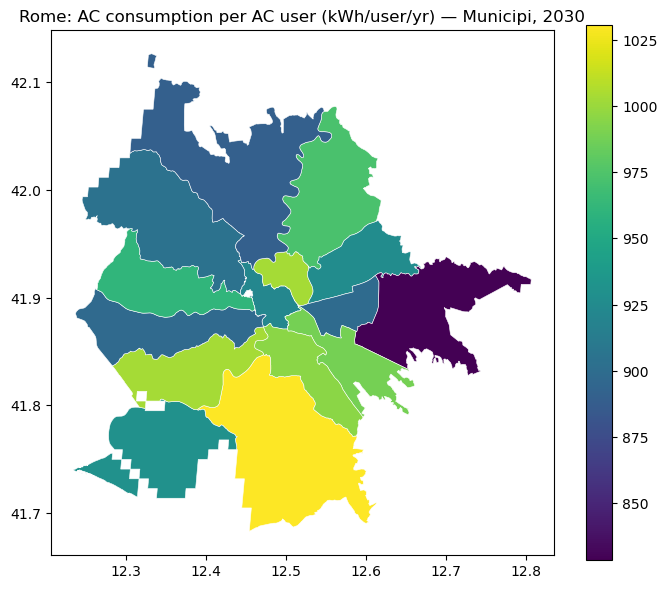

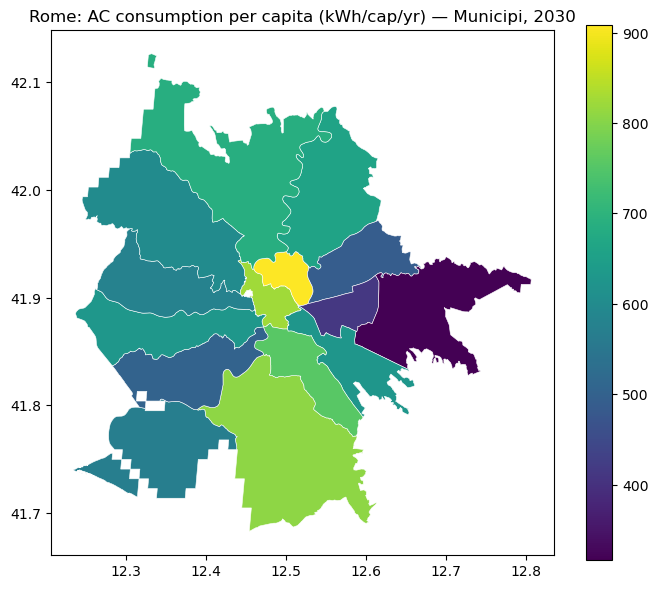


==== Municipio-level results for year 2040 ====
City diagnostics by universe:
[ALL FUA] per-user=954.202406 AC-share=0.715 total=1738.238 GWh pop=2,548,154 users=1,821,666
[Municipi-only (muni_on_ref>0)] per-user=952.688218 AC-share=0.713 total=1634.595 GWh pop=2,406,440 users=1,715,771
[Outside Municipi (muni_id==0)] per-user=978.732585 AC-share=0.747 total=103.643 GWh pop=141,714 users=105,895

Check: in + out should equal all
users: 1821666.15625 vs 1821666.0
GWh:  1738.237856 vs 1738.23808

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 954.2021970295815
City total GWh: 1738.237860642685

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.949971,1003.785215,161260.130027,1.537723e+08,953.566574,2040
1,9,0.849129,1031.023132,218657.720215,1.914285e+08,875.471182,2040
2,1,0.945610,924.473400,179186.877781,1.566435e+08,874.190889,2040
3,8,0.823958,995.611461,113650.658718,9.323238e+07,820.341754,2040
4,15,0.832714,888.331927,99254.233600,7.342101e+07,739.726710,2040
5,3,0.738391,972.604531,148399.737608,1.065750e+08,718.161958,2040
6,12,0.762065,897.222636,131663.470656,9.002386e+07,683.742149,2040
7,7,0.691030,988.385418,248261.719912,1.695638e+08,683.004392,2040
8,14,0.719988,904.221021,158462.193480,1.031634e+08,651.028277,2040
9,13,0.651550,960.450533,130701.853861,8.179083e+07,625.781720,2040


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.413376,828.368893,129944.772669,4.449671e+07,342.427884,2040
1,5,0.498481,898.314901,175712.888959,7.868296e+07,447.792790,2040
2,4,0.573658,926.113973,170679.730356,9.067755e+07,531.273082,2040
3,11,0.543187,1003.017903,119803.339214,6.527203e+07,544.826469,2040
4,10,0.661970,929.446368,220800.462973,1.358509e+08,615.265401,2040
5,13,0.651550,960.450533,130701.853861,8.179083e+07,625.781720,2040
6,14,0.719988,904.221021,158462.193480,1.031634e+08,651.028277,2040
7,7,0.691030,988.385418,248261.719912,1.695638e+08,683.004392,2040
8,12,0.762065,897.222636,131663.470656,9.002386e+07,683.742149,2040
9,3,0.738391,972.604531,148399.737608,1.065750e+08,718.161958,2040



Top 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.849129,1031.023132,218657.720215,1.914285e+08,875.471182,2040
1,7,0.691030,988.385418,248261.719912,1.695638e+08,683.004392,2040
2,1,0.945610,924.473400,179186.877781,1.566435e+08,874.190889,2040
3,2,0.949971,1003.785215,161260.130027,1.537723e+08,953.566574,2040
4,10,0.661970,929.446368,220800.462973,1.358509e+08,615.265401,2040
5,3,0.738391,972.604531,148399.737608,1.065750e+08,718.161958,2040
6,14,0.719988,904.221021,158462.193480,1.031634e+08,651.028277,2040
7,8,0.823958,995.611461,113650.658718,9.323238e+07,820.341754,2040
8,4,0.573658,926.113973,170679.730356,9.067755e+07,531.273082,2040
9,12,0.762065,897.222636,131663.470656,9.002386e+07,683.742149,2040


Bottom 10 Municipi by kwh_muni — Total kWh, 2040


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.413376,828.368893,129944.772669,4.449671e+07,342.427884,2040
1,11,0.543187,1003.017903,119803.339214,6.527203e+07,544.826469,2040
2,15,0.832714,888.331927,99254.233600,7.342101e+07,739.726710,2040
3,5,0.498481,898.314901,175712.888959,7.868296e+07,447.792790,2040
4,13,0.651550,960.450533,130701.853861,8.179083e+07,625.781720,2040
5,12,0.762065,897.222636,131663.470656,9.002386e+07,683.742149,2040
6,4,0.573658,926.113973,170679.730356,9.067755e+07,531.273082,2040
7,8,0.823958,995.611461,113650.658718,9.323238e+07,820.341754,2040
8,14,0.719988,904.221021,158462.193480,1.031634e+08,651.028277,2040
9,3,0.738391,972.604531,148399.737608,1.065750e+08,718.161958,2040


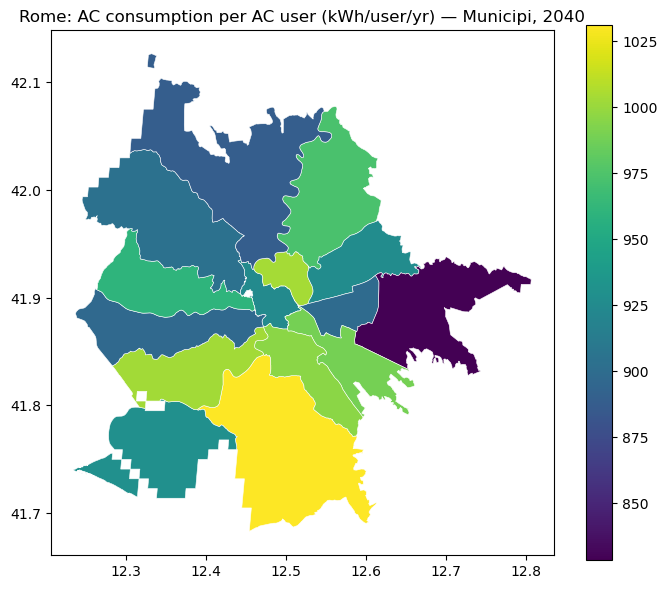

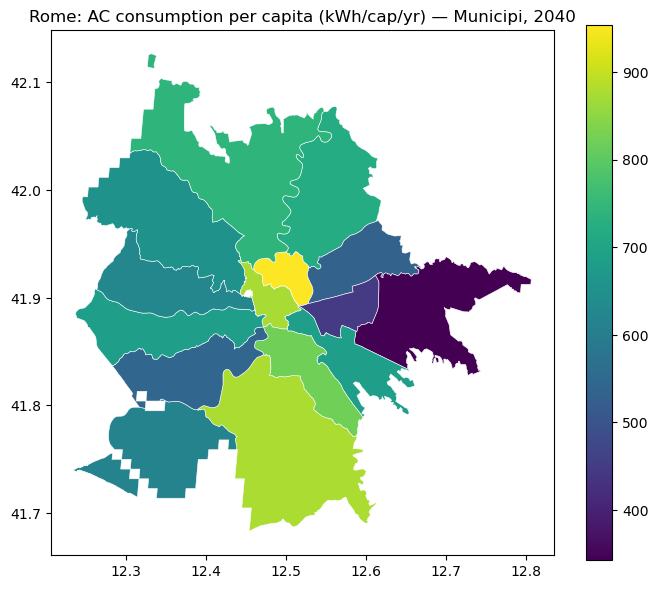


==== Municipio-level results for year 2050 ====
City diagnostics by universe:
[ALL FUA] per-user=1001.772048 AC-share=0.715 total=1824.894 GWh pop=2,548,154 users=1,821,666
[Municipi-only (muni_on_ref>0)] per-user=1000.183376 AC-share=0.713 total=1716.086 GWh pop=2,406,440 users=1,715,771
[Outside Municipi (muni_id==0)] per-user=1027.512757 AC-share=0.747 total=108.809 GWh pop=141,714 users=105,895

Check: in + out should equal all
users: 1821666.15625 vs 1821666.0
GWh:  1824.894256 vs 1824.89408

From groupby (includes muni_id=0):
Users-weighted per-user mean (city): 1001.7720615460015
City total GWh: 1824.894258855788

Top 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,2,0.949971,1053.826870,161260.130027,1.614383e+08,1001.104672,2050
1,9,0.849129,1082.385316,218657.720215,2.009649e+08,919.084269,2050
2,1,0.945610,970.568150,179186.877781,1.644539e+08,917.778515,2050
3,8,0.823958,1045.219268,113650.658718,9.787782e+07,861.216472,2050
4,15,0.832714,932.598403,99254.233600,7.707965e+07,776.588030,2050
5,3,0.738391,1021.117481,148399.737608,1.118909e+08,753.983464,2050
6,12,0.762065,941.990159,131663.470656,9.451567e+07,717.857926,2050
7,7,0.691030,1037.651653,248261.719912,1.780158e+08,717.048861,2050
8,14,0.719988,949.309515,158462.193480,1.083076e+08,683.491436,2050
9,13,0.651550,1008.339390,130701.853861,8.586899e+07,656.983691,2050


Bottom 10 Municipi by kwh_pc_overall — kWh per capita (overall), 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.413376,869.680507,129944.772669,4.671581e+07,359.505109,2050
1,5,0.498481,943.090071,175712.888959,8.260480e+07,470.112363,2050
2,4,0.573658,972.274784,170679.730356,9.519724e+07,557.753622,2050
3,11,0.543187,1053.049796,119803.339214,6.852789e+07,572.003140,2050
4,10,0.661970,975.802803,220800.462973,1.426265e+08,645.951949,2050
5,13,0.651550,1008.339390,130701.853861,8.586899e+07,656.983691,2050
6,14,0.719988,949.309515,158462.193480,1.083076e+08,683.491436,2050
7,7,0.691030,1037.651653,248261.719912,1.780158e+08,717.048861,2050
8,12,0.762065,941.990159,131663.470656,9.451567e+07,717.857926,2050
9,3,0.738391,1021.117481,148399.737608,1.118909e+08,753.983464,2050



Top 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,9,0.849129,1082.385316,218657.720215,2.009649e+08,919.084269,2050
1,7,0.691030,1037.651653,248261.719912,1.780158e+08,717.048861,2050
2,1,0.945610,970.568150,179186.877781,1.644539e+08,917.778515,2050
3,2,0.949971,1053.826870,161260.130027,1.614383e+08,1001.104672,2050
4,10,0.661970,975.802803,220800.462973,1.426265e+08,645.951949,2050
5,3,0.738391,1021.117481,148399.737608,1.118909e+08,753.983464,2050
6,14,0.719988,949.309515,158462.193480,1.083076e+08,683.491436,2050
7,8,0.823958,1045.219268,113650.658718,9.787782e+07,861.216472,2050
8,4,0.573658,972.274784,170679.730356,9.519724e+07,557.753622,2050
9,12,0.762065,941.990159,131663.470656,9.451567e+07,717.857926,2050


Bottom 10 Municipi by kwh_muni — Total kWh, 2050


,muni_id,ac_share_muni,kwh_per_user_muni,pop_muni,kwh_muni,kwh_pc_overall,year
0,6,0.413376,869.680507,129944.772669,4.671581e+07,359.505109,2050
1,11,0.543187,1053.049796,119803.339214,6.852789e+07,572.003140,2050
2,15,0.832714,932.598403,99254.233600,7.707965e+07,776.588030,2050
3,5,0.498481,943.090071,175712.888959,8.260480e+07,470.112363,2050
4,13,0.651550,1008.339390,130701.853861,8.586899e+07,656.983691,2050
5,12,0.762065,941.990159,131663.470656,9.451567e+07,717.857926,2050
6,4,0.573658,972.274784,170679.730356,9.519724e+07,557.753622,2050
7,8,0.823958,1045.219268,113650.658718,9.787782e+07,861.216472,2050
8,14,0.719988,949.309515,158462.193480,1.083076e+08,683.491436,2050
9,3,0.738391,1021.117481,148399.737608,1.118909e+08,753.983464,2050


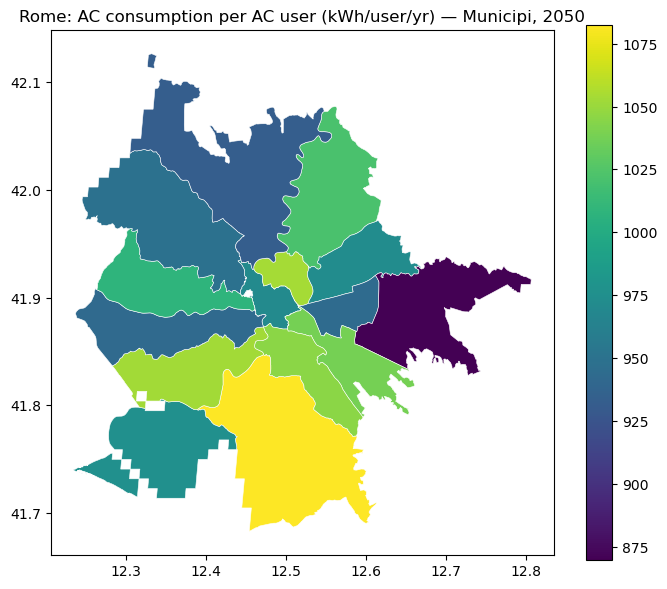

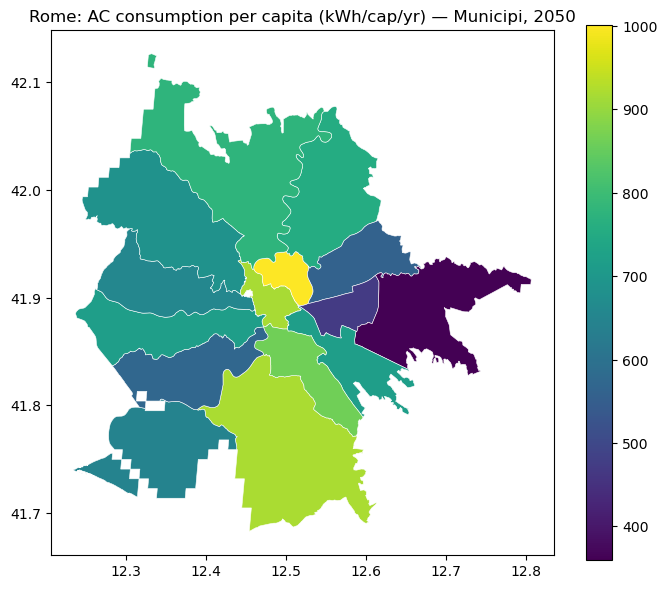

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_summary.csv
Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_muni_ac_consumption_map.geojson


In [10]:
# Municipio-level AC electricity: per-user, per-capita, totals over multiple years
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path

years_maps = [2030, 2040, 2050]
assert 'muni_on_ref' in globals(), "muni_on_ref raster missing."
assert 'muni' in globals() and isinstance(muni, gpd.GeoDataFrame), "muni GeoDataFrame missing."

pop_grid = pop_on_ref

def _wavg(x, w):
    x = np.asarray(x, float)
    w = np.asarray(w, float)
    s = np.nansum(w)
    return float(np.nansum(x * w) / s) if s > 0 else np.nan

def show_rank_muni(df_in, col, k=10, title=""):
    cols = ["muni_id","ac_share_muni","kwh_per_user_muni", "pop_muni","kwh_muni","kwh_pc_overall","year"]
    top = df_in[cols].sort_values(col, ascending=False).head(k).reset_index(drop=True)
    bot = df_in[cols].sort_values(col, ascending=True).head(k).reset_index(drop=True)
    print(f"\nTop {k} Municipi by {col} — {title}"); display(top)
    print(f"Bottom {k} Municipi by {col} — {title}"); display(bot)

all_muni_tbl = []
all_muni_map = []

for year_map in years_maps:
    print(f"\n==== Municipio-level results for year {year_map} ====")

    coverage_map = _cov_for_year(year_map)
    per_user_map = per_user_map_by_year[year_map]
    kwh_tot_map = kwh_tot_map_by_year[year_map]

    def city_diag(mask, label):
        users = float(np.nansum((coverage_map * pop_grid)[mask]))
        per_user = float(np.nansum((per_user_map * coverage_map * pop_grid)[mask]) / max(users, 1e-12))
        kwh = float(np.nansum(kwh_tot_map[mask])) / 1e6
        pop = float(np.nansum(pop_grid[mask]))
        print(f"[{label}] per-user={per_user:.6f} AC-share={users/pop:.3f} "
              f"total={kwh:.3f} GWh pop={pop:,.0f} users={users:,.0f}")
        return per_user, users, kwh

    # universes (keep id==0 as "outside" bucket)
    mask_all = CITY_MASK
    mask_in = CITY_MASK & (muni_on_ref > 0)
    mask_out = CITY_MASK & (muni_on_ref == 0)

    print("City diagnostics by universe:")
    pu_all, u_all, k_all = city_diag(mask_all, "ALL FUA")
    pu_in, u_in, k_in = city_diag(mask_in, "Municipi-only (muni_on_ref>0)")
    pu_out, u_out, k_out = city_diag(mask_out, "Outside Municipi (muni_id==0)")

    print("\nCheck: in + out should equal all")
    print("users:", u_in + u_out, "vs", u_all)
    print("GWh: ", k_in + k_out, "vs", k_all)

    # Build pixel to Municipio table over the full city mask (includes muni_id==0)
    valid_all = (CITY_MASK & np.isfinite(per_user_map) & np.isfinite(kwh_tot_map) & np.isfinite(pop_grid) & np.isfinite(coverage_map))
    df = pd.DataFrame({
        "muni_id": muni_on_ref[valid_all].ravel().astype(int), # includes 0
        "pop": pop_grid[valid_all].ravel().astype(float),
        "users": (coverage_map[valid_all] * pop_grid[valid_all]).ravel().astype(float),
        "kwh": kwh_tot_map[valid_all].ravel().astype(float),
        "per_user": per_user_map[valid_all].ravel().astype(float),
    })

    # users-weighted per-user by municipio
    per_user_by_muni = (df.groupby("muni_id")
                        .apply(lambda g: _wavg(g["per_user"], g["users"]))
                        .reset_index(name="kwh_per_user_muni"))

    # totals by municipio
    muni_tbl_all = (df.groupby("muni_id", as_index=False)
                    .agg(pop_muni=("pop","sum"), users_muni=("users","sum"), kwh_muni=("kwh","sum"))
                    .merge(per_user_by_muni, on="muni_id", how="left"))

    # rates
    muni_tbl_all["ac_share_muni"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["users_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["kwh_pc_overall"] = np.where(muni_tbl_all["pop_muni"] > 0, muni_tbl_all["kwh_muni"] / muni_tbl_all["pop_muni"], np.nan)
    muni_tbl_all["year"] = year_map
    all_muni_tbl.append(muni_tbl_all)

    # city diagnostics from grouped table
    users_sum = float(muni_tbl_all["users_muni"].sum())
    per_user_from_groups = float(
        np.nansum(muni_tbl_all["kwh_per_user_muni"] * muni_tbl_all["users_muni"]) / max(users_sum, 1e-12)
    )
    kwh_sum = float(muni_tbl_all["kwh_muni"].sum()) / 1e6
    print("\nFrom groupby (includes muni_id=0):")
    print("Users-weighted per-user mean (city):", per_user_from_groups)
    print("City total GWh:", kwh_sum)

    # tables and maps for Municipi only (exclude id==0 for reporting)
    muni_only = muni_tbl_all[muni_tbl_all["muni_id"] > 0].copy()
    show_rank_muni(muni_only, "kwh_pc_overall", k=10, title=f"kWh per capita (overall), {year_map}")
    show_rank_muni(muni_only, "kwh_muni", k=10, title=f"Total kWh, {year_map}")

    # map join
    muni_map = (muni[["muni_id","muni_name","geometry"]] if "muni_name" in muni.columns else muni[["muni_id","geometry"]]).merge(muni_only, on="muni_id", how="left")
    muni_map["year"] = year_map
    muni_map_4326 = muni_map.to_crs("EPSG:4326")
    all_muni_map.append(muni_map_4326)

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_per_user_muni", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per AC user (kWh/user/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(1,1, figsize=(7,6))
    muni_map_4326.plot(ax=ax, column="kwh_pc_overall", legend=True, linewidth=0.4, edgecolor="white")
    ax.set_title(f"{CITY}: AC consumption per capita (kWh/cap/yr) — Municipi, {year_map}")
    plt.tight_layout(); plt.show()

# saving all years together
OUT = Path(OUT); OUT.mkdir(parents=True, exist_ok=True)

muni_tbl_all_years = pd.concat(all_muni_tbl, ignore_index=True)
muni_csv = OUT / f"{SLUG}_muni_ac_consumption_summary.csv"
(muni_tbl_all_years
 .assign(kwh_GWh=lambda d: d["kwh_muni"]/1e6)
 .to_csv(muni_csv, index=False))

muni_map_all = gpd.GeoDataFrame(pd.concat(all_muni_map, ignore_index=True), crs="EPSG:4326")
muni_geo = OUT / f"{SLUG}_muni_ac_consumption_map.geojson"
(muni_map_all[["muni_id","geometry","year", "kwh_per_user_muni","ac_share_muni","kwh_pc_overall","kwh_muni"]]
 .to_file(muni_geo, driver="GeoJSON"))

print("Saved:", muni_csv)
print("Saved:", muni_geo)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Why do the maps per AC user and per capita look different? Because the denominator is not the same. Per-AC_user varies because we draw CAP-level kWh/user around the city mean and scale it to match the city target. The map reflects only usage among households that have AC while the per-capita divides this same energy across everyone in the CAP. It equals AC share*per-AC-user. So places with low ownership look much lower per-capita even if users there consume a lot. Conversely, places with high ownership look high even if users don't consume unusually much. Finally, about the Municipi vs CAP, municipio values are population-weighted aggregates of the CAPs inside them. Rankings of totals differ because total kWh = per-capita * population. 
</blockquote>